In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(
    "../data/processed/news_dataset.csv"
)

df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 44898
Columns: 5
<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 112.3 MB


In [4]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(209)

In [6]:
df["label"].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

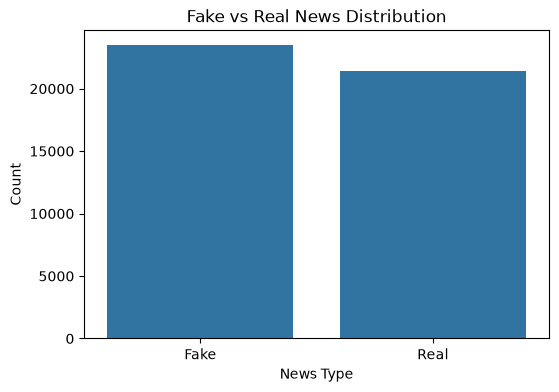

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Fake vs Real News Distribution")
plt.xlabel("News Type")
plt.ylabel("Count")

plt.xticks(
    [0,1],
    ["Fake", "Real"]
)

plt.show()

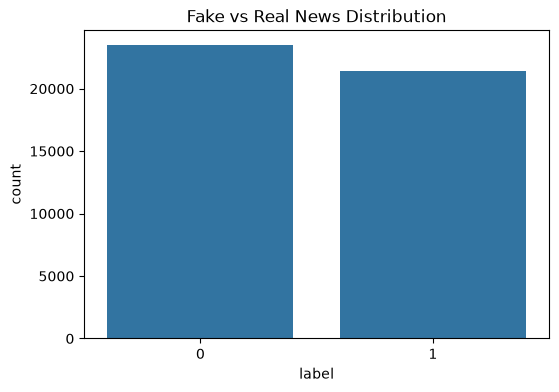

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Fake vs Real News Distribution")

plt.savefig(
    "../reports/figures/class_distribution.png"
)

plt.show()

In [9]:
df["text_length"] = df["text"].apply(len)

df.head()

,title,text,subject,date,label,text_length
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,1028
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,4820
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,1848
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,1244
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,3137


In [10]:
df.groupby("label")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,23481.0,2547.396235,2532.884399,1.0,1433.0,2166.0,3032.0,51794.0
1,21417.0,2383.278517,1684.835730,1.0,914.0,2222.0,3237.0,29781.0


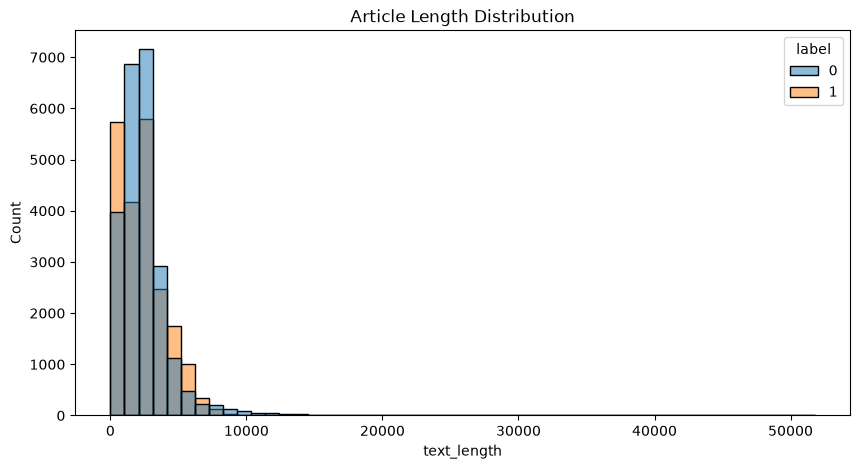

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="text_length",
    hue="label",
    bins=50
)

plt.title(
    "Article Length Distribution"
)

plt.show()

In [12]:
df["word_count"] = df["text"].apply(
    lambda x: len(str(x).split())
)

df.head()

,title,text,subject,date,label,text_length,word_count
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,1028,171
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,4820,771
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,1848,304
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,1244,183
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,3137,529


In [13]:
df.groupby(
    "label"
)["word_count"].mean()

label
0    423.197905
1    385.640099
Name: word_count, dtype: float64

In [14]:
df["subject"].value_counts()

subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

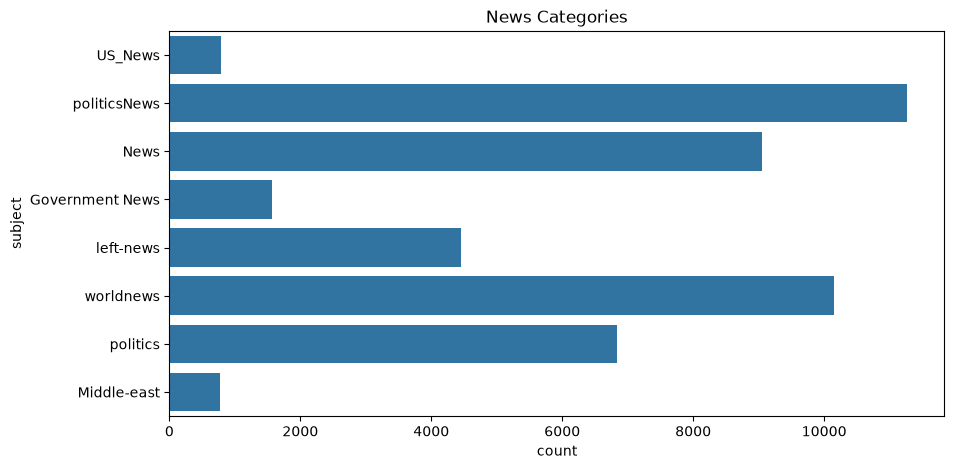

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="subject"
)

plt.title(
    "News Categories"
)

plt.show()

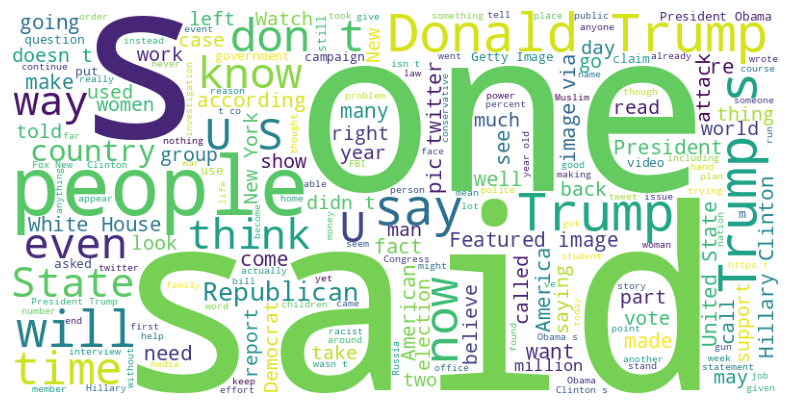

In [16]:
fake_text = " ".join(
    df[df["label"]==0]["text"]
)


wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(fake_text)


plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [17]:
wordcloud.to_file(
    "../reports/figures/fake_wordcloud.png"
)